# WORKSHOP - 5: License Plate Detection using OpenCV and Haar Cascade Classifier

### **Name:** THENAMIZHTHAN V   **Reg.** 212225240175

In [12]:
import cv2

cascade_path = r"C:\Users\acer\Downloads\haarcascade_russian_plate_number.xml"

plate_cascade = cv2.CascadeClassifier(cascade_path)

print("XML loaded:", not plate_cascade.empty())

XML loaded: True


Plates detected: 1


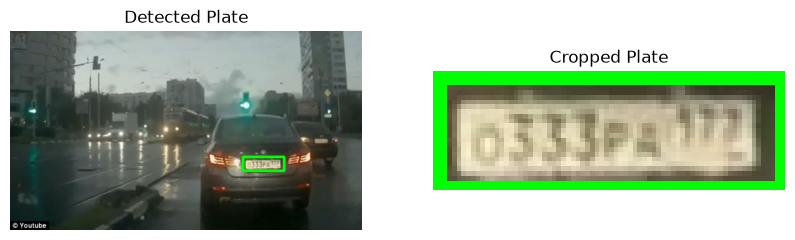

In [20]:
img = cv2.imread("car_plate.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plates = plate_cascade.detectMultiScale(
    blurred,
    scaleFactor=1.1,
    minNeighbors=4
)

print("Plates detected:", len(plates))

import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cropped_plate = None

for (x, y, w, h) in plates:
    # Draw rectangle
    cv2.rectangle(
        img_rgb,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    # Crop plate
    cropped_plate = img_rgb[y:y+h, x:x+w]

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Detected Plate")
plt.imshow(img_rgb)
plt.axis("off")

if cropped_plate is not None:
    plt.subplot(1, 2, 2)
    plt.title("Cropped Plate")
    plt.imshow(cropped_plate)
    plt.axis("off")

plt.show()